## 05．モデル訓練
Optunaが見つけたパラメータで最終モデルを訓練

予測結果は np.expm1 で元のWVPの単位に逆変換し、決定係数 R^2 や平均絶対誤差 MAE、誤差率 MAPE を算出

②ex_idでくくる

クロスバリデーションあり

In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error

# ==========================================
# 1. データのロードと準備
# ==========================================
df_clean = pd.read_csv(r"C:\Users\scarl\Downloads\大学関連\25講義関連\b3後期\b4\coating_ML2\coating_ML_260618\data\interim\260625\wvp_adjustment\01_cleaned_raw.csv")
df_desc = pd.read_csv(r"C:\Users\scarl\Downloads\大学関連\25講義関連\b3後期\b4\coating_ML2\coating_ML_260618\data\interim\260625\wvp_adjustment\02_molecular_descriptors.csv")

# 特徴量とターゲットの結合
X_raw = pd.concat([
    df_clean[['experiment_id', 'humidity', 'temperature', 'material_concentration', 'proportion']].reset_index(drop=True), 
    df_desc
], axis=1)
y_raw = df_clean['wvp'].reset_index(drop=True)

# 欠損値排除
valid_idx = X_raw.notna().all(axis=1)
X_valid = X_raw[valid_idx].copy()
y_valid = np.log1p(y_raw[valid_idx])  # WVPの対数変換

# グループ（実験ID）の抽出
groups = X_valid['experiment_id'].values
X = X_valid.drop(columns=['experiment_id'])
y = y_valid.values

# ==========================================
# 2. グループ付きクロスバリデーション (GroupKFold)
# ==========================================
# 5つの実験グループ群に均等に分割
gkf = GroupKFold(n_splits=5)

params = {
    'n_estimators': 150,
    'max_depth': 4,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1
}

cv_train_r2 = []
cv_test_r2 = []
cv_test_mae = []

print(f"--- 🔄 GroupKFold (5-Fold) 交差検証を開始します --- \n")

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups)):
    # データの分割
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # モデルの訓練
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)
    
    # 予測（対数スケール）
    train_preds_log = model.predict(X_train)
    test_preds_log = model.predict(X_test)
    
    # 元のWVP単位に逆変換 (np.expm1)
    y_train_orig = np.expm1(y_train)
    y_test_orig = np.expm1(y_test)
    train_preds_orig = np.expm1(train_preds_log)
    test_preds_orig = np.expm1(test_preds_log)
    
    # スコア計算
    tr_r2 = r2_score(y_train_orig, train_preds_orig)
    te_r2 = r2_score(y_test_orig, test_preds_orig)
    te_mae = mean_absolute_error(y_test_orig, test_preds_orig)
    
    cv_train_r2.append(tr_r2)
    cv_test_r2.append(te_r2)
    cv_test_mae.append(te_mae)
    
    print(f"Fold {fold+1}: Train R² = {tr_r2:.4f} | Test R² = {te_r2:.4f} | Test MAE = {te_mae:.4f}")

# ==========================================
# 3. 最終結果のレポート
# ==========================================
print("\n" + "="*40)
print("      📊 クロスバリデーション 最終結果      ")
print("="*40)
print(f" 訓練データ平均 R² : {np.mean(cv_train_r2):.4f}")
print(f" テストデータ平均 R²  : {np.mean(cv_test_r2):.4f}")
print(f" テストデータ平均 MAE : {np.mean(cv_test_mae):.4f}")
print("="*40)

--- 🔄 GroupKFold (5-Fold) 交差検証を開始します --- 

Fold 1: Train R² = 0.6863 | Test R² = -1.1351 | Test MAE = 0.9287
Fold 2: Train R² = 0.7291 | Test R² = -0.6654 | Test MAE = 0.8781
Fold 3: Train R² = 0.6705 | Test R² = -0.3693 | Test MAE = 0.7386
Fold 4: Train R² = 0.7235 | Test R² = -1.0335 | Test MAE = 1.1093
Fold 5: Train R² = 0.5285 | Test R² = -0.6412 | Test MAE = 1.2185

      📊 クロスバリデーション 最終結果      
 訓練データ平均 R² : 0.6676
 テストデータ平均 R²  : -0.7689
 テストデータ平均 MAE : 0.9746


※optunaの04反映

In [3]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error
import ast  # テキストの辞書型を読み込むためのライブラリ

# ==========================================
# 1. データのロードと準備
# ==========================================
df_clean = pd.read_csv(r"C:\Users\scarl\Downloads\大学関連\25講義関連\b3後期\b4\coating_ML2\coating_ML_260618\data\interim\260625\wvp_adjustment\01_cleaned_raw.csv")
df_desc = pd.read_csv(r"C:\Users\scarl\Downloads\大学関連\25講義関連\b3後期\b4\coating_ML2\coating_ML_260618\data\interim\260625\wvp_adjustment\02_molecular_descriptors.csv")

# 特徴量とターゲットの結合
X_raw = pd.concat([
    df_clean[['experiment_id', 'humidity', 'temperature', 'material_concentration', 'proportion']].reset_index(drop=True), 
    df_desc
], axis=1)
y_raw = df_clean['wvp'].reset_index(drop=True)

# 欠損値排除
valid_idx = X_raw.notna().all(axis=1)
X_valid = X_raw[valid_idx].copy()
y_valid = np.log1p(y_raw[valid_idx])  # WVPの対数変換

# グループ（実験ID）の抽出
groups = X_valid['experiment_id'].values
X = X_valid.drop(columns=['experiment_id'])
y = y_valid.values

# ==========================================
# 2. 💡【修正】Optunaのベストパラメータを自動ロード
# ==========================================
param_path = r"C:\Users\scarl\Downloads\大学関連\25講義関連\b3後期\b4\coating_ML2\coating_ML_260618\data\interim\260625\wvp_adjustment\04_best_params_optuna.txt"

try:
    with open(param_path, "r") as f:
        params = ast.literal_eval(f.read())
    print("✅ 04_optuna で見つけた最適なパラメータを自動ロードしました。")
    
    # 以前のエラー防止用の固定パラメータも一応裏でセット（random_stateなど）
    params['random_state'] = 42
    params['n_jobs'] = -1
except FileNotFoundError:
    print("⚠️ パラメータファイルが見つからないため、手動設定の値を使用します。")
    params = {
        'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.05,
        'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'n_jobs': -1
    }

# ==========================================
# 3. グループ付きクロスバリデーション (GroupKFold)
# ==========================================
gkf = GroupKFold(n_splits=5)

cv_train_r2 = []
cv_test_r2 = []
cv_test_mae = []

print(f"\n--- 🔄 GroupKFold (5-Fold) 交差検証を開始します --- \n")

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups)):
    # データの分割
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # モデルの訓練
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)
    
    # 予測（対数スケール）
    train_preds_log = model.predict(X_train)
    test_preds_log = model.predict(X_test)
    
    # 元のWVP単位に逆変換 (np.expm1)
    y_train_orig = np.expm1(y_train)
    y_test_orig = np.expm1(y_test)
    train_preds_orig = np.expm1(train_preds_log)
    test_preds_orig = np.expm1(test_preds_log)
    
    # スコア計算
    tr_r2 = r2_score(y_train_orig, train_preds_orig)
    te_r2 = r2_score(y_test_orig, test_preds_orig)
    te_mae = mean_absolute_error(y_test_orig, test_preds_orig)
    
    cv_train_r2.append(tr_r2)
    cv_test_r2.append(te_r2)
    cv_test_mae.append(te_mae)
    
    print(f"Fold {fold+1}: Train R² = {tr_r2:.4f} | Test R² = {te_r2:.4f} | Test MAE = {te_mae:.4f}")

# ==========================================
# 4. 最終結果のレポート
# ==========================================
print("\n" + "="*40)
print("      📊 クロスバリデーション 最終結果      ")
print("="*40)
print(f" 訓練データ平均 R² : {np.mean(cv_train_r2):.4f}")
print(f" テストデータ平均 R²  : {np.mean(cv_test_r2):.4f}")
print(f" テストデータ平均 MAE : {np.mean(cv_test_mae):.4f}")
print("="*40)

✅ 04_optuna で見つけた最適なパラメータを自動ロードしました。

--- 🔄 GroupKFold (5-Fold) 交差検証を開始します --- 

Fold 1: Train R² = 0.1835 | Test R² = -0.0370 | Test MAE = 0.5925
Fold 2: Train R² = 0.2147 | Test R² = -0.1362 | Test MAE = 0.7152
Fold 3: Train R² = 0.2029 | Test R² = -0.0799 | Test MAE = 0.6896
Fold 4: Train R² = 0.1663 | Test R² = -0.1134 | Test MAE = 0.8588
Fold 5: Train R² = 0.1029 | Test R² = -0.7924 | Test MAE = 1.2705

      📊 クロスバリデーション 最終結果      
 訓練データ平均 R² : 0.1741
 テストデータ平均 R²  : -0.2318
 テストデータ平均 MAE : 0.8253


In [6]:
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# 1. データのロードと精鋭特徴量の抽出
csv_path = r"C:\Users\scarl\Downloads\大学関連\25講義関連\b3後期\b4\coating_ML2\coating_ML_260618\data\processed\260625\processed_data.csv"
df = pd.read_csv(csv_path)

base_features = ['humidity', 'temperature']  
weighted_features = [col for col in df.columns if col.startswith('weighted_')]
selected_features = base_features + weighted_features

X_raw = df[selected_features]
y_raw = df['wvp']
groups = df['experiment_id'].values

valid_idx = X_raw.notna().all(axis=1) & y_raw.notna()
X = X_raw[valid_idx].copy()
y = np.log1p(y_raw[valid_idx]).values
groups = groups[valid_idx]

# 2. 目的関数の定義（23列のデータに合わせた学習能力の再調整）
def objective(trial):
    params = {
        # データが綺麗になったので、もう少し複雑なルールを学べるように探索範囲を広げます
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8), 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),       
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0), 
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'random_state': 42,
        'n_jobs': -1
    }
    
    gkf = GroupKFold(n_splits=5)
    cv_test_r2 = []
    
    for train_idx, test_idx in gkf.split(X, y, groups=groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        model = xgb.XGBRegressor(**params)
        model.fit(X_train, y_train)
        
        test_preds_orig = np.expm1(model.predict(X_test))
        y_test_orig = np.expm1(y_test)
        
        cv_test_r2.append(r2_score(y_test_orig, test_preds_orig))
    
    return np.mean(cv_test_r2)

# 3. 最適化の実行
if __name__ == "__main__":
    print(f"--- 🤖 精鋭特徴量(23列)専用のOptuna最適化を開始します (サンプル数: {X.shape[0]}) ---")
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=50, timeout=600) # 50回探索
    
    print("\n" + "="*40)
    print("      🏆 最適化が完了しました！      ")
    print("="*40)
    print(f"★ 改善された最高の平均 Test R²: {study.best_value:.4f}")
    print("★ 見つかった最適なパラメータ:")
    for k, v in study.best_params.items():
        print(f"  - {k}: {v}")
    print("="*40)
    
    # パラメータの保存
    param_path = r"C:\Users\scarl\Downloads\大学関連\25講義関連\b3後期\b4\coating_ML2\coating_ML_260618\data\interim\260625\04_best_params_optuna.txt"
    with open(param_path, "w") as f:
        f.write(str(study.best_params))
    print(f"📁 新しい最適パラメータを '{param_path}' に上書き保存しました。")

--- 🤖 精鋭特徴量(23列)専用のOptuna最適化を開始します (サンプル数: 388) ---

      🏆 最適化が完了しました！      
★ 改善された最高の平均 Test R²: -0.0796
★ 見つかった最適なパラメータ:
  - n_estimators: 126
  - max_depth: 3
  - learning_rate: 0.014306007880817878
  - subsample: 0.630156017395053
  - colsample_bytree: 0.7079577276555516
  - min_child_weight: 1
📁 新しい最適パラメータを 'C:\Users\scarl\Downloads\大学関連\25講義関連\b3後期\b4\coating_ML2\coating_ML_260618\data\interim\260625\04_best_params_optuna.txt' に上書き保存しました。


26/06/26

In [2]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error
import ast

# ==========================================
# 1. 重み付け済みマスターデータの読み込み
# ==========================================
csv_path = r"C:\Users\scarl\Downloads\大学関連\25講義関連\b3後期\b4\coating_ML2\coating_ML_260618\data\processed\260625\processed_data.csv"
df = pd.read_csv(csv_path)

# 環境変数・配合情報と、'weighted_' で始まるモル重み付け平均の列だけを抽出
base_features = ['humidity', 'temperature']  
weighted_features = [col for col in df.columns if col.startswith('weighted_')]

selected_features = base_features + weighted_features

X_raw = df[selected_features]
y_raw = df['wvp']
groups = df['experiment_id'].values

# 欠損値排除とターゲットの対数変換 (log1p)
valid_idx = X_raw.notna().all(axis=1) & y_raw.notna()
X = X_raw[valid_idx].copy()
y = np.log1p(y_raw[valid_idx]).values
groups = groups[valid_idx]

print(f"--- 🧹 特徴量のノイズ除去が完了しました ---")
print(f"・総サンプル数（実験数）: {X.shape[0]} 行")
print(f"・厳選された特徴量数     : {X.shape[1]} 列\n")

# ==========================================
# 2. Optunaパラメータのロード
# ==========================================
param_path = r"C:\Users\scarl\Downloads\大学関連\25講義関連\b3後期\b4\coating_ML2\coating_ML_260618\data\interim\260625\04_best_params_optuna.txt"
try:
    with open(param_path, "r") as f:
        params = ast.literal_eval(f.read())
    params['random_state'] = 42
    params['n_jobs'] = -1
    print("✅ 04_optuna から最適化パラメータをロードしました。")
except FileNotFoundError:
    print("⚠️ パラメータファイルがないため、厳格な過学習防止パラメータを使用します。")
    params = {
        'n_estimators': 100, 
        'max_depth': 3,         
        'learning_rate': 0.05,
        'subsample': 0.7, 
        'colsample_bytree': 0.7, 
        'random_state': 42, 
        'n_jobs': -1
    }

# ==========================================
# 3. グループ付きクロスバリデーション (GroupKFold) の実行
# ==========================================
gkf = GroupKFold(n_splits=5)

cv_train_r2 = []
cv_test_r2 = []
cv_test_mae = []

print(f"\n--- 🔄 精鋭特徴量による GroupKFold (5-Fold) を開始します --- \n")

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups)):
    # ─── 🛠️【ここを修正しました】インデックス指定を追加 ───
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # モデルの訓練
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)
    
    # 予測と元の単位への逆変換 (expm1)
    y_train_orig = np.expm1(y_train)
    y_test_orig = np.expm1(y_test)
    train_preds_orig = np.expm1(model.predict(X_train))
    test_preds_orig = np.expm1(model.predict(X_test))
    
    # 指標の計算
    tr_r2 = r2_score(y_train_orig, train_preds_orig)
    te_r2 = r2_score(y_test_orig, test_preds_orig)
    te_mae = mean_absolute_error(y_test_orig, test_preds_orig)
    
    cv_train_r2.append(tr_r2)
    cv_test_r2.append(te_r2)
    cv_test_mae.append(te_mae)
    
    print(f"Fold {fold+1}: Train R² = {tr_r2:.4f} | Test R² = {te_r2:.4f} | Test MAE = {te_mae:.4f}")

# ==========================================
# 4. 最終結果の表示
# ==========================================
print("\n" + "="*40)
print(" 📊 ノイズ除去モデル（weighted_のみ） 最終結果 ")
print("="*40)
print(f" 訓練データ平均 R² : {np.mean(cv_train_r2):.4f}")
print(f" テストデータ平均 R²  : {np.mean(cv_test_r2):.4f}")
print(f" テストデータ平均 MAE : {np.mean(cv_test_mae):.4f}")
print("="*40)

--- 🧹 特徴量のノイズ除去が完了しました ---
・総サンプル数（実験数）: 388 行
・厳選された特徴量数     : 23 列

✅ 04_optuna から最適化パラメータをロードしました。

--- 🔄 精鋭特徴量による GroupKFold (5-Fold) を開始します --- 

Fold 1: Train R² = 0.4923 | Test R² = -0.3104 | Test MAE = 1.4920
Fold 2: Train R² = 0.3986 | Test R² = 0.1180 | Test MAE = 1.3165
Fold 3: Train R² = 0.4419 | Test R² = -0.1131 | Test MAE = 1.4806
Fold 4: Train R² = 0.3857 | Test R² = -0.0352 | Test MAE = 1.6287
Fold 5: Train R² = 0.4616 | Test R² = -0.0526 | Test MAE = 1.2751

 📊 ノイズ除去モデル（weighted_のみ） 最終結果 
 訓練データ平均 R² : 0.4360
 テストデータ平均 R²  : -0.0787
 テストデータ平均 MAE : 1.4386


クロスバリデーションなし

In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import ast

def train_and_evaluate(X_train, X_test, y_train, y_test, best_params):
    print("--- Step 5: 最終モデル訓練 & 逆変換精度評価 ---")

    # 最適なパラメータでモデルを構築・訓練
    best_model = xgb.XGBRegressor(**best_params, random_state=42, n_jobs=-1)
    best_model.fit(X_train, y_train)

    # 予測を出力（対数スケール）
    train_preds_log = best_model.predict(X_train)
    test_preds_log = best_model.predict(X_test)

    # 逆変換：np.expm1 を使って元のWVP単位に戻す
    y_train_orig = np.expm1(y_train)
    y_test_orig = np.expm1(y_test)
    train_preds_orig = np.expm1(train_preds_log)
    test_preds_orig = np.expm1(test_preds_log)

    # MAPE（平均絶対誤差率）計算
    mask = y_test_orig != 0
    test_mape = np.mean(np.abs((y_test_orig[mask] - test_preds_orig[mask]) / y_test_orig[mask])) * 100

    # ─── 最終精度レポートの出力 ───
    print("\n" + "="*40)
    print("    📊 モデル精度評価レポート (最終結果)    ")
    print("="*40)
    print(f"【決定係数: R²】 (1.0に近いほど高性能)")
    print(f"  - 訓練データ (Train R²): {r2_score(y_train_orig, train_preds_orig):.4f}")
    print(f"  - テストデータ (Test R² ): {r2_score(y_test_orig, test_preds_orig):.4f}")
    print("-" * 40)
    print(f"【予測エラー指標】 (元のWVP単位での評価)")
    print(f"  - 二乗平均平方根誤差 (RMSE): {np.sqrt(mean_squared_error(y_test_orig, test_preds_orig)):.4f}")
    print(f"  - 平均絶対誤差       (MAE) : {mean_absolute_error(y_test_orig, test_preds_orig):.4f}")
    print(f"  - 平均絶対誤差率     (MAPE): {test_mape:.2f} %")
    print("-" * 40)

    # 誤差の分布統計
    errors = test_preds_orig - y_test_orig
    abs_errors = np.abs(errors)
    print("【テストデータの誤差分布統計】")
    print(f"  - 平均してズレている絶対量: {np.mean(abs_errors):.4f}")
    print(f"  - 最大の予測ハズレ（最大誤差）: {np.max(abs_errors):.4f}")
    print(f"  - 予測の標準偏差（ばらつき）  : {np.std(errors):.4f}")
    print("="*40)

    return best_model

#実行用
if __name__ == "__main__":
    # 1. Step 3 で保存したデータファイルを絶対パスで読み込む
    import_path = r"C:\Users\scarl\Downloads\大学関連\25講義関連\b3後期\b4\coating_ML2\coating_ML_260618\data\interim\260625\03_2_split_dataset.npz"
    data = np.load(import_path, allow_pickle=True)

    cols = data['columns'].tolist()
    X_train = pd.DataFrame(data['X_train'], columns=cols)
    X_test = pd.DataFrame(data['X_test'], columns=cols)
    y_train = data['y_train']
    y_test = data['y_test']

    # 2. Step 4 でテキスト保存したベストパラメータを自動で読み込む
    param_path = r"C:\Users\scarl\Downloads\大学関連\25講義関連\b3後期\b4\coating_ML2\coating_ML_260618\data\interim\260625\04_2_best_params.txt"
    try:
        with open(param_path, "r") as f:
            best_params = ast.literal_eval(f.read())
        print("Step 4 の最適パラメータを自動ロードしました。")
    except FileNotFoundError:
        # 万が一テキストファイルがない場合は、ここに手動で 04 の結果の辞書をコピペしてください
        print("⚠️ パラメータファイルが見つからないため、デフォルト値を使用します。")
        best_params = {'n_estimators': 331, 'max_depth': 9, 'learning_rate': 0.169}

    # 3. モデルの訓練と精度評価を実行
    final_model = train_and_evaluate(X_train, X_test, y_train, y_test, best_params)

Step 4 の最適パラメータを自動ロードしました。
--- Step 5: 最終モデル訓練 & 逆変換精度評価 ---

    📊 モデル精度評価レポート (最終結果)    
【決定係数: R²】 (1.0に近いほど高性能)
  - 訓練データ (Train R²): 0.0901
  - テストデータ (Test R² ): -0.0432
----------------------------------------
【予測エラー指標】 (元のWVP単位での評価)
  - 二乗平均平方根誤差 (RMSE): 1.5875
  - 平均絶対誤差       (MAE) : 1.1689
  - 平均絶対誤差率     (MAPE): 241.78 %
----------------------------------------
【テストデータの誤差分布統計】
  - 平均してズレている絶対量: 1.1689
  - 最大の予測ハズレ（最大誤差）: 6.2414
  - 予測の標準偏差（ばらつき）  : 1.5594


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importance(model, feature_names):
    # 1. モデルから重要度を取得
    importances = model.feature_importances_

    # 2. データフレームにまとめる
    df_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False).reset_index(drop=True)

    # 3. テキストでランキングを出力
    print("\n" + "="*40)
    print("      🏆 特徴量重要度ランキング      ")
    print("="*40)
    for idx, row in df_importance.iterrows():
        # 【修正】 :02d のあとの「位」を波括弧の外に出しました
        print(f" {idx+1:02d}位: {row['Feature']:<25} ({row['Importance']*100:.2f} %)")
    print("="*40)


# 実行用
if __name__ == "__main__":
    try:
        feature_names = X_train.columns.tolist()
        df_imp = plot_feature_importance(final_model, feature_names)
    except NameError:
        print("⚠️ final_model または X_train が見つかりません。")
        print("05_final_training.ipynb の最終行にこのコードを貼り付けて実行してください。")


      🏆 特徴量重要度ランキング      
 01位: temperature               (10.94 %)
 02位: material_concentration    (9.28 %)
 03位: MaxAbsPartialCharge       (8.85 %)
 04位: FractionCSP3              (8.17 %)
 05位: BalabanJ                  (6.67 %)
 06位: humidity                  (6.61 %)
 07位: HallKierAlpha             (6.40 %)
 08位: Kappa2                    (5.27 %)
 09位: HeavyAtomMolWt            (4.10 %)
 10位: NOCount                   (3.72 %)
 11位: RingCount                 (3.56 %)
 12位: NumHeteroatoms            (3.56 %)
 13位: proportion                (3.38 %)
 14位: Kappa1                    (2.70 %)
 15位: NumHAcceptors             (2.60 %)
 16位: TPSA                      (2.60 %)
 17位: MolMR                     (2.52 %)
 18位: LabuteASA                 (2.31 %)
 19位: MolLogP                   (2.15 %)
 20位: ExactMolWt                (1.81 %)
 21位: NumRotatableBonds         (1.09 %)
 22位: NHOHCount                 (0.93 %)
 23位: NumHDonors                (0.77 %)
 24位: HeavyAtomCount         

--- Step 7: 実測値 vs 予測値の散布図（対角線プロット）の作成 ---


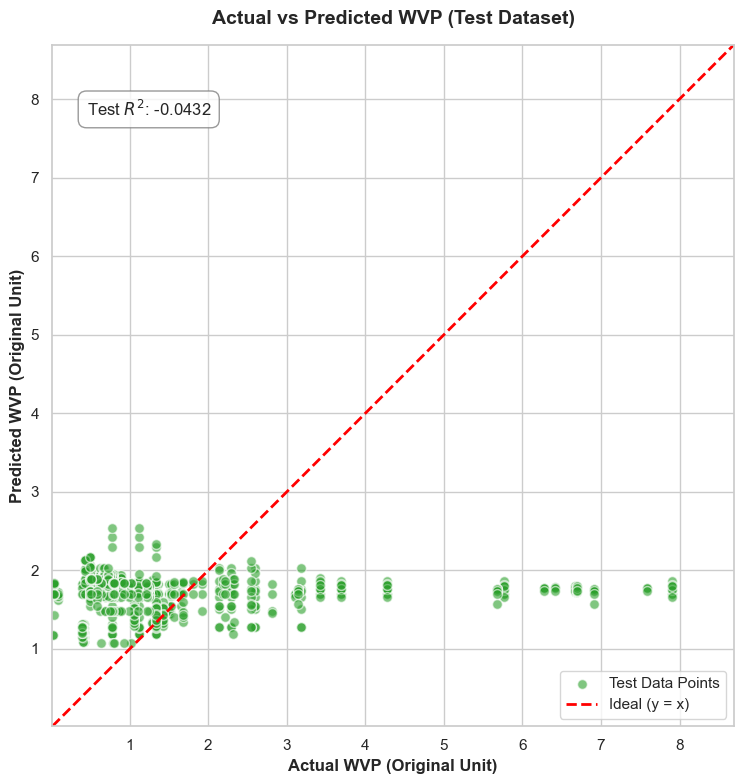

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

def plot_predicted_vs_actual(model, X_test, y_test):
    print("--- Step 7: 実測値 vs 予測値の散布図（対角線プロット）の作成 ---")
    
    # 1. テストデータに対する予測を出力（対数スケール）
    preds_log = model.predict(X_test)
    
    # 2. 元のWVP単位に逆変換 (np.expm1)
    y_actual = np.expm1(y_test)
    y_pred = np.expm1(preds_log)
    
    # 3. グラフの描画設定
    plt.figure(figsize=(8, 8), dpi=100)
    sns.set_theme(style="whitegrid")
    
    # 散布図のプロット
    plt.scatter(y_actual, y_pred, color='#2ca02c', alpha=0.6, edgecolors='w', s=50, label='Test Data Points')
    
    # 4. 理想的な対角線 (y = x) の描画
    min_val = min(y_actual.min(), y_pred.min()) * 0.9
    max_val = max(y_actual.max(), y_pred.max()) * 1.1
    
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal (y = x)')
    
    # 5. グラフの装飾・テキスト追加
    plt.title('Actual vs Predicted WVP (Test Dataset)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Actual WVP (Original Unit)', fontsize=12, fontweight='bold')
    plt.ylabel('Predicted WVP (Original Unit)', fontsize=12, fontweight='bold')
    
    # グラフ内にR²の値を表示する
    r2_test = r2_score(y_actual, y_pred)
    text_box = f"Test $R^2$: {r2_test:.4f}"
    plt.gca().text(0.05, 0.92, text_box, transform=plt.gca().transAxes, fontsize=12,
                   verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))
    
    # 軸の範囲を等しくして正方形にする
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.legend(loc='lower right', fontsize=11)
    plt.gca().set_aspect('equal', adjustable='box')
    
    plt.tight_layout()
    plt.show()

# ─── 実行部分 ───
if __name__ == "__main__":
    try:
        # 05の final_model, X_test, y_test をそのまま使用します
        plot_predicted_vs_actual(final_model, X_test, y_test)
    except NameError:
        print("⚠️ final_model, X_test, y_test のいずれかが見つかりません。05のノートブックの最下部で実行してください。")